In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor

from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [2]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "test"

In [3]:
def meta_one_hot_shot(meta, para_nm):
    meta = meta.transpose()
    meta_one_hot = pd.DataFrame(False, index=meta.index, columns=para_nm)
    for index, row in meta.iterrows():
        for r in row.values:
            meta_one_hot.loc[index, para_nm[r]] = True

    return meta_one_hot

In [4]:
class EmulatedDataStorage:
    """
    Lightweight container for emulation outputs.
    No computation logic.
    """
    def __init__(self):
        pass

In [5]:
def sample_from_hull(X, para, h):

    minx, miny, maxx, maxy = h.bounds
    p1, p2 = para

    X = X[
        (X[p1] >= minx) & (X[p1] <= maxx) &
        (X[p2] >= miny) & (X[p2] <= maxy)
    ]

    if X.empty:
        return X
    
    pts = points(X[list(para)].values)
    tf = contains(h,pts)
    
    return X.loc[tf].reset_index(drop=True)

In [125]:
def _one_batch(args):
    para_l, para_nm, grouped_hulls, n_pts, seed = args

    rng = np.random.default_rng(seed)

    
    X = pd.DataFrame(
        rng.uniform(0, 1, size=(n_pts, len(para_nm))),
        columns=para_nm
    )

    for para in para_l:
        h = grouped_hulls[para]
        X = sample_from_hull(X, para, h)

        if X.shape[0] == 0:
            return None

    return X



In [248]:
def test_ind_vars(X_prev, X, para_nm, tf_masks, grouped_hulls, para, paras_vars, shape_alpha = 5):
    print(f'\t \tRunning test to see if {para} could be break down and lead to non-overlapping')

    vars = paras_vars[para]
    if len(vars) == 1:
        return None
    for i in reversed(range(len(vars))):
        print(f'Try {i} combinations')
        var_combs = combinations(vars, i)
        for var_comb in var_combs:
            print('Try one of the combinations')
            X_sub = X[tf_masks[list(var_comb)].all(axis = 1)]
            if X_sub.shape[0] > 5000:
                X_sub = X_sub.sample(5000)
            
            X_sub = X_sub[list(para)].values
            hull_sub = alphashape.alphashape(X_sub, shape_alpha)

            attempt = sample_from_hull(X_prev, para, hull_sub)
            
            if not attempt.empty:
                print(f'\t \t \t Found the good variable combo')
                drop_vars = [x for x in vars if x not in list(var_comb)]
                return list(var_comb), drop_vars, hull_sub
            else:
                pass 

        if i -1 == 0:
            print(f'\t \t \t No variable combinations work')
            return None

In [260]:
def sample_from_hulls_n(
    para_l,
    para_nm,
    grouped_hulls,
    n_pts=100_000,
    n_threshold=100_000,
    max_workers=None,
    sample_threshold = 10**7
):
    if max_workers is None:
        max_workers = os.cpu_count() -1     
    
    
    out = []
    count = 0
    n_sampled = 0
    
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = []
        MAX_IN_FLIGHT = 2 * max_workers

        while (count < n_threshold) and (n_sampled < sample_threshold):
            while (count < n_threshold) and (len(futures) < MAX_IN_FLIGHT) and (n_sampled < sample_threshold):
                seed = np.random.randint(0, 2**32 - 1)# changed
                
                futures.append(ex.submit(_one_batch,
                    (para_l, para_nm, grouped_hulls, n_pts,seed),))

                n_sampled = n_sampled + n_pts

            
            # harvest finished jobs
            for fut in as_completed(list(futures)):
                futures.remove(fut)
                X = fut.result()
                out.append(X)

                
                if X is not None:
                    count += X.shape[0]
        
                
                
        if all([x is None for x in out]):
            print(f'Find nothing from {sample_threshold} pts')
            return None
    
    out = [x for x in out if x is not None]
    out = pd.concat(out, axis=0).reset_index(drop = True)
    return out



In [295]:
def orchestrate_test(para_seq, X, tf_masks, para_nm, grouped_hulls, paras_vars, n_pts=10000, n_threshold=10000, sample_threshold = 10**7, max_workers=None):
    para_l = []
    para_non_over = []
    var_drop = {}
    
    non_over_count = 0
    for p_count, p in enumerate(para_seq):
        print(f'Running {p}, the {p_count}th simulation')
        para_l.append(p)
        out = sample_from_hulls_n(para_l, para_nm, grouped_hulls, n_pts=  n_pts, n_threshold = n_threshold, sample_threshold = sample_threshold, max_workers = max_workers)
        
        if out is None:
            print("Find nothing, try to resolve it by breaking the variables into groups")
            print("First sample out_prev that needs greater sample size, which will take long")
            out_prev = sample_from_hulls_n(para_l[:-1], para_nm, grouped_hulls, n_pts=  n_pts, n_threshold = n_threshold, max_workers = max_workers, sample_threshold=sample_threshold * 120)
            print(f'The size of out_prev is {out_prev.shape[0]}')
            if out_prev is None:
                print("out_prev issue")
    
            check_pt = test_ind_vars(out_prev, X, para_nm, tf_masks, grouped_hulls, p, paras_vars, shape_alpha = 5)
            if check_pt is None:
                para_l.remove(p)
                del grouped_hulls[p]
                print(f'\t \t \t \t {p} is causing trouble and is skipped')
                non_over_count = non_over_count + 1
                para_non_over.append(p)
                
                
            else:
                print(f'\t \t \t \t Modify the original hull and variable')
                print(f'\t \t \t \t Drop {check_pt[1]}')
                grouped_hulls[p] = check_pt[2]
                paras_vars[p] = check_pt[0]
                var_drop[p] = check_pt[1]
                
        else:
            print(f'There is overlap for {p}. Proceed to the next parameter pair')
            

        print("======================================================================")

    
        # if non_over_count > 5:
        #     print("Too many non-overlapping, break the loop")
        #     return para_l, para_non_over

        
        
    return para_l, para_non_over, grouped_hulls, paras_vars, var_drop, out_prev

In [302]:
para_seq = list(test_case.grouped_hulls.keys())[:15]
check = orchestrate_test(para_seq, test_case.p_emu, test_case.tf_masks,  test_case.para_nm, test_case.grouped_hulls, test_case.paras_vars, n_pts=  10000, n_threshold = 100,sample_threshold = 10**5, max_workers = 31)

## Add random seed generator for the batch sampling method

Running ('clubb_C8', 'microp_aero_wsub_min')
There is overlap for ('clubb_C8', 'microp_aero_wsub_min'). Proceed to the next parameter pair
Running ('clubb_C8', 'microp_aero_wsubi_scale')
There is overlap for ('clubb_C8', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('dust_emis_fact', 'microp_aero_wsubi_scale')
Find nothing from 100000 pts
Find nothing, try to resolve it by breaking the variables into groups
First sample out_prev that needs greater sample size, which will take long
The size of out_prev is 16116
	 	Running test to see if ('dust_emis_fact', 'microp_aero_wsubi_scale') could be break down and lead to non-overlapping
Try 8 combinations
Try one of the combinations
Try one of the combinations
Try one of the combinations
Try one of the combinations
Try one of the combinations
Try one of the combinations
Try one of the combinations
Try one of the combinations
	 	 	 Found the good variable combo
	 	 	 	 Modify the original hull and variable
	 	 	 	 Drop 

In [304]:
pts = sample_from_hulls_n(list(check[2].keys())[:15], test_case.para_nm, check[2],n_pts=50000, n_threshold=5000,max_workers=32,sample_threshold=10**8)


In [305]:
pts

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
0,0.717481,0.655254,0.032446,0.721807,0.757208,0.849285,0.276364,0.272555,0.583480,0.571921,...,0.780427,0.106459,0.625564,0.281432,0.433844,0.289172,0.392828,0.589066,0.468679,0.189211
1,0.399035,0.830557,0.220663,0.888497,0.961610,0.609981,0.925114,0.395975,0.595672,0.385777,...,0.578850,0.259019,0.374189,0.881989,0.411433,0.157830,0.733921,0.752034,0.460149,0.276792
2,0.553574,0.562252,0.600243,0.242353,0.968290,0.301465,0.524629,0.269695,0.608246,0.580905,...,0.690034,0.432872,0.862849,0.736599,0.282618,0.238961,0.701795,0.733696,0.431661,0.241193
3,0.555581,0.510020,0.486798,0.607664,0.638380,0.927395,0.826618,0.350399,0.611472,0.344890,...,0.942610,0.329706,0.727440,0.086536,0.058189,0.177739,0.358373,0.714589,0.446181,0.288866
4,0.491167,0.973625,0.368139,0.725085,0.729030,0.488723,0.533889,0.759983,0.604066,0.015763,...,0.726630,0.494812,0.844292,0.698194,0.375483,0.251221,0.426511,0.330043,0.483440,0.844226
5,0.898249,0.608116,0.507325,0.187974,0.700619,0.027226,0.588590,0.354177,0.610794,0.444314,...,0.525999,0.384473,0.833729,0.921204,0.653013,0.213198,0.586057,0.045564,0.441383,0.920286
6,0.896327,0.311640,0.426715,0.666380,0.213966,0.522828,0.254956,0.462834,0.593111,0.102429,...,0.886427,0.261111,0.662121,0.056258,0.178757,0.182395,0.004037,0.423210,0.448644,0.825951
7,0.434302,0.535087,0.203684,0.652255,0.961858,0.874785,0.704454,0.010999,0.608968,0.972680,...,0.036353,0.923650,0.472970,0.673187,0.595052,0.240083,0.687219,0.192232,0.418909,0.859418
8,0.398885,0.092298,0.454403,0.549675,0.232156,0.303823,0.653249,0.559090,0.596111,0.813882,...,0.943615,0.051201,0.946659,0.653570,0.579307,0.157374,0.657897,0.186015,0.460977,0.780523
9,0.019350,0.533750,0.258118,0.465499,0.184011,0.087092,0.651227,0.291153,0.569422,0.570217,...,0.970122,0.511719,0.600709,0.878121,0.052425,0.128388,0.947833,0.953316,0.488499,0.912207


In [306]:
pts = sample_from_hulls_n(list(check[2].keys())[:5], test_case.para_nm, check[2],n_pts=50000, n_threshold=5000,sample_threshold=10**8,max_workers=32)
pts.head()

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
0,0.458174,0.467109,0.294542,0.804598,0.396397,0.239799,0.341688,0.918578,0.553233,0.775874,...,0.381315,0.579864,0.671861,0.420453,0.208277,0.215476,0.489183,0.985240,0.537921,0.970825
1,0.845069,0.684898,0.043103,0.267495,0.713074,0.695765,0.817098,0.015312,0.580106,0.525918,...,0.416536,0.297453,0.838567,0.842234,0.962809,0.275011,0.054637,0.467455,0.488970,0.888280
2,0.756753,0.178489,0.977610,0.286773,0.721442,0.012818,0.622762,0.751775,0.541287,0.003133,...,0.971410,0.080117,0.530461,0.896090,0.827983,0.325359,0.115717,0.320298,0.550336,0.698222
3,0.644512,0.532384,0.486430,0.470606,0.240153,0.111987,0.054266,0.171817,0.578062,0.202516,...,0.722983,0.173609,0.420818,0.865941,0.689564,0.141134,0.197220,0.214059,0.490371,0.908779
4,0.217523,0.240875,0.501144,0.834641,0.861651,0.674814,0.486635,0.339514,0.606150,0.145758,...,0.031980,0.398492,0.737128,0.933461,0.439146,0.227624,0.081498,0.165688,0.467637,0.018043


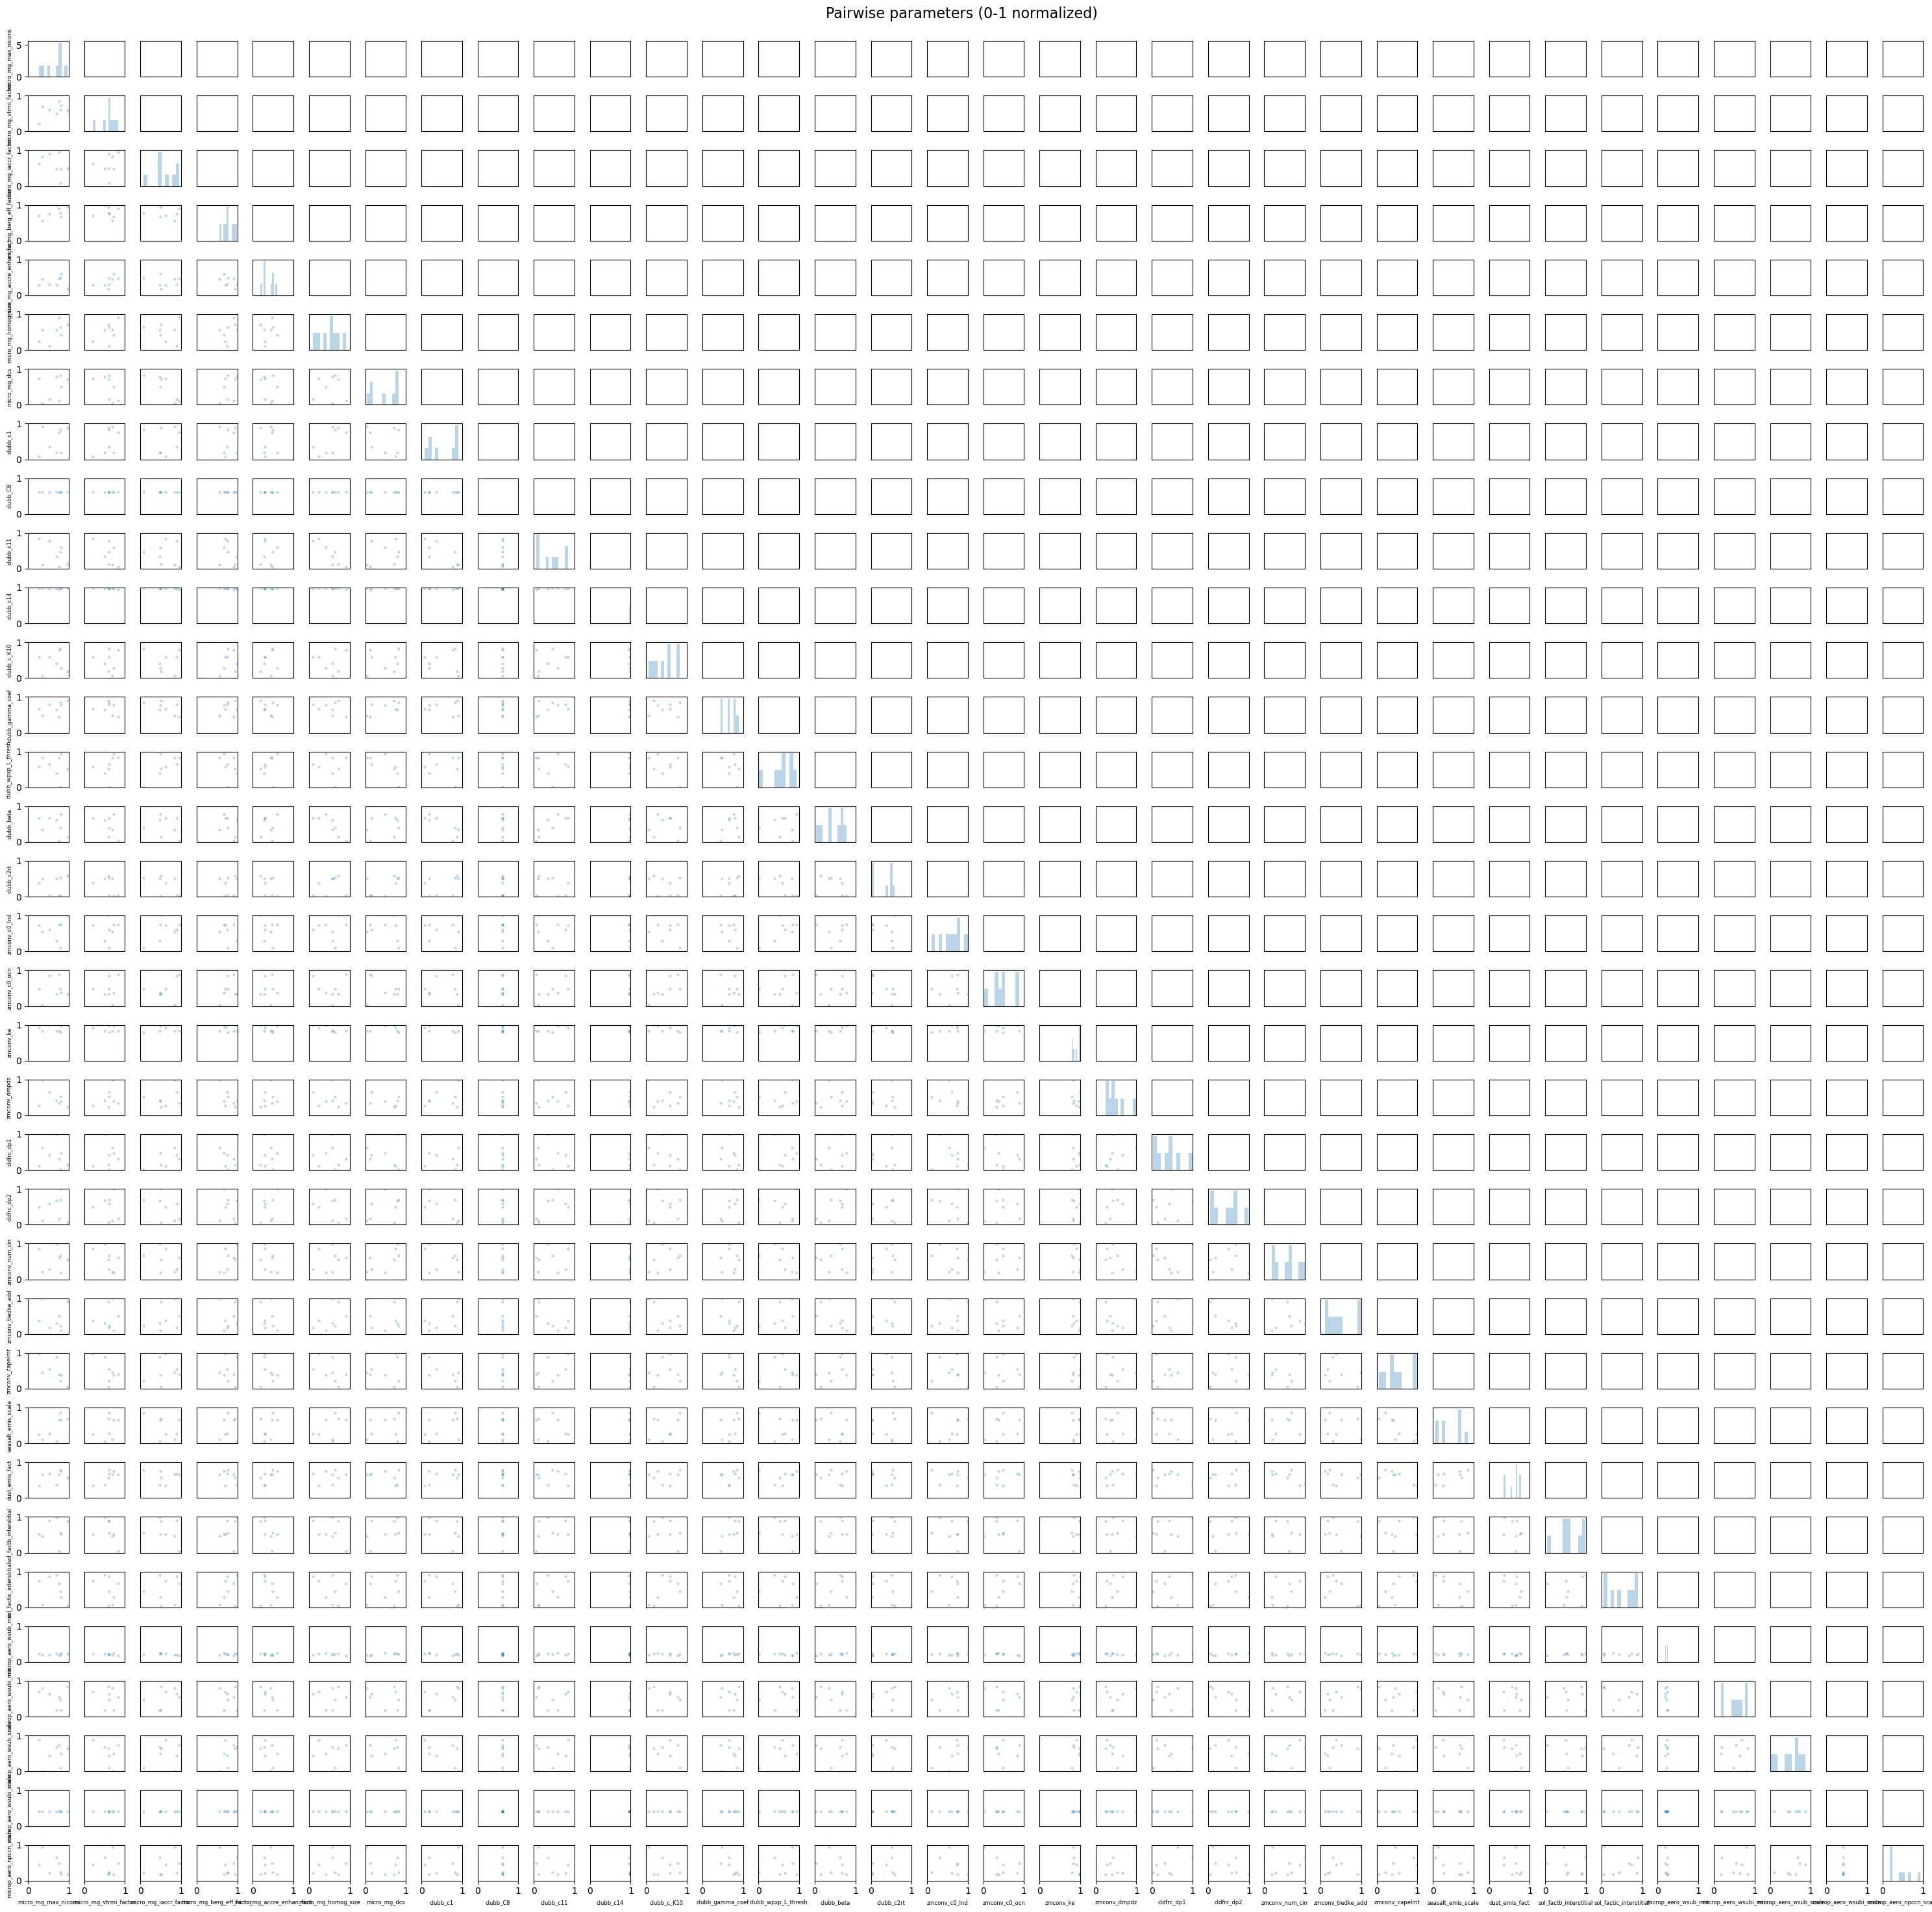

In [263]:
biplot(check[-1])

In [21]:
# def sample_from_hull_above_n(para_l, para_nm, grouped_hulls, n_pts = 100000, n_threshold = 100000):
#     out = []
#     count = 0
#     while count < n_threshold:
#         X = pd.DataFrame(np.random.uniform(0, 1, (n_pts, len(para_nm))), columns = para_nm)
#         for para in para_l:
#             h = grouped_hulls[para]    
#             X = sample_from_hull(X, para, h)
            
#             if X.shape[0] == 0:
#                 print(f'Break by {para}')
#                 return None               
            
#         out.append(X)
#         count = count + X.shape[0]
                
#     out = pd.concat(out, axis = 0)
#     return out

In [10]:
def sample_from_hulls(X, paras, grouped_hulls):
    X = X
    for p in paras:
        h = grouped_hulls[p]
        X = sample_from_hull(X, p, h)
        if X.shape[0] == 0:
            print(f'Break by {para}')
            return None
            
    return X, X.shape[0]

In [11]:
class HistoryMatching:
    def __init__(self, working_dir, case_name, threshold_level = 2.0):
        self.root = Path(working_dir) / case_name
        self.tf_masks = pd.read_csv(self.root / f'tf_masks_level_{threshold_level}.csv', index_col=0)
        self.meta = pd.read_csv(self.root / 'meta.csv', index_col = 0)
        self.p_emu = xr.open_dataset(self.root / 'sampled_parameters.nc').to_dataframe()
        self.var_nm = list(self.tf_masks.columns)
        self.para_nm = list(self.p_emu.columns)

        self.tf_masks_raw = self.tf_masks

        self.dropped_vars = EmulatedDataStorage()
        self.n_sample = self.tf_masks.shape[0]

        self.dropped_vars.nooverlap2d = []
    def drop_by_name(self, var_to_exclude):
        var_to_drop = []
        for v in var_to_exclude:
            var_to_drop.extend([s for s in self.var_nm if s.startswith(v)])
        
        self.tf_masks = self.tf_masks.drop(columns = var_to_drop)

        self.var_nm = list(self.tf_masks.columns)
        self.dropped_vars.by_name = var_to_drop

    def drop_by_n_survive(self, n_survive):
        survive_summary = self.tf_masks.sum(axis = 0)
        self.dropped_vars.useless = list(survive_summary[survive_summary == self.n_sample].index)
        self.dropped_vars.tight   = list(survive_summary[survive_summary < n_survive].index)

        self.tf_masks = self.tf_masks.drop(columns = self.dropped_vars.useless + self.dropped_vars.tight)
        
        self.var_nm = list(self.tf_masks.columns)

    def update_meta(self, occurence_threshold = 2):
        self.meta = self.meta[self.var_nm]
        self.meta_onehot = meta_one_hot_shot(self.meta, self.para_nm)
        p_occur_count = self.meta_onehot.sum(axis = 0)
        self.p_occur_count = p_occur_count
        
#        p_sensitive = list(p_occur_count[p_occur_count > occurence_threshold].index)
#        self.meta_onehot = self.meta_onehot[p_sensitive]

    def hull_for_each(self, shape_alpha = 5):
        hull_per_var = {}
        for v in self.var_nm:
            p_ind = self.meta[v].sort_values().values
            pts = self.p_emu[self.tf_masks[v]].iloc[:,p_ind]
            if pts.shape[0] > 5000:
               pts = pts.sample(5000)

            pts = pts.values
            
            hull_per_var[v] = alphashape.alphashape(pts, shape_alpha)

        self.hull_per_var = hull_per_var

    def group_para_climatology(self):

        vars = self.var_nm
        paras_vars = {}
        paras_vars_0 = {}    
        for c in vars: 
            para_inds = self.meta[c].sort_values().values
            para_nms = [self.para_nm[ind] for ind in para_inds]
            paras_vars.setdefault(tuple(para_nms), []).append(c)



        paras_vars = dict(
                sorted(paras_vars.items(), key=lambda item: len(item[1]), reverse=True)
        )
        
        self.paras_vars = paras_vars
        
        
        for k, v in paras_vars.items():
            temp_count = self.tf_masks[v].all(axis = 1).sum()
            print(f'{k[0]:<40} and {k[1]:<40}: {temp_count:>8}')
            if temp_count < 10000:
                paras_vars_0[k] = v

        self.paras_vars_0 = paras_vars_0

        
        
    def shuffle_vars(self, n_comb = 2):
        summary_table = {}
    
        for paras, vars in self.paras_vars_0.items():
            
            vars_temp = vars 
            pd_list = []
            
            for vars_comb in combinations(vars_temp, n_comb):
                pd_list.append(list(vars_comb) + [self.tf_masks[list(vars_comb)].all(axis = 1).sum()])
                
            pd_list = pd.DataFrame(pd_list, columns = [f"var{i+1}" for i in range(n_comb)] + ["count"])
            pd_list = pd_list.sort_values(by = "count")
            
            
            summary_table[paras] = pd_list

        print(f'There are {len(self.paras_vars_0)} groups that have no overlapping within own groups')
        return summary_table

    def drop_no_overlap2d_vars(self, vars_to_drop):
        self.tf_masks = self.tf_masks.drop(columns = vars_to_drop)
        self.var_nm = list(self.tf_masks.columns)
        self.meta = self.meta[self.var_nm]
        self.meta_onehot = meta_one_hot_shot(self.meta, self.para_nm)
        self.dropped_vars.nooverlap2d.append(vars_to_drop)

        
    
    def visualize(self, para_pair):
        para_pair = tuple(para_pair)
        survive_pts = self.p_emu[self.tf_masks[self.paras_vars[para_pair]].all(axis = 1)]

        if survive_pts.shape[0] > 5000:
            survive_pts = survive_pts.sample(5000)

        return survive_pts

    def build_hulls(self, shape_alpha = 5):
        grouped_hulls = {}

        for para2, vars in self.paras_vars.items():

            tf_mask = self.tf_masks[vars].all(axis = 1)
            pts = self.p_emu[tf_mask]
            if pts.shape[0] > 5000:
                pts = pts.sample(5000)
            
            pts_np = pts[list(para2)].values
            
            grouped_hulls[para2] = alphashape.alphashape(pts_np, shape_alpha)
            
            
        self.grouped_hulls = grouped_hulls
    
    

    

In [297]:
test_case = HistoryMatching(working_dir, case_name)
test_case.drop_by_name(["TGCLDLWP", "CLDTOT"])
test_case.drop_by_n_survive(n_survive = 100000)
test_case.update_meta()

In [298]:
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()

clubb_C8                                 and microp_aero_wsub_min                    :   314967
clubb_C8                                 and microp_aero_wsubi_scale                 :    48436
dust_emis_fact                           and microp_aero_wsubi_scale                 :        0
clubb_c14                                and microp_aero_wsubi_scale                 :   176779
micro_mg_berg_eff_factor                 and microp_aero_wsubi_scale                 :        0
clubb_c2rt                               and zmconv_dmpdz                            :   869194
clubb_c2rt                               and microp_aero_wsubi_scale                 :        0
clubb_C8                                 and zmconv_capelmt                          :        0
clubb_C8                                 and cldfrc_dp1                              :   684794
zmconv_capelmt                           and seasalt_emis_scale                      :   548406
clubb_c14                               

In [299]:
no_overlap_2d_vars = ["FLUT_zonal_55to60", 'LWCF_zonal_-70to-65', 'FLUT_zonal_-60to-55', 
                      'FLUT_zonal_-55to-50', 'FLUT_zonal_-65to-60', 'SWCF_zonal_-60to-55', 
                      'SWCF_zonal_-55to-50', 'LWCF_zonal_70to75', 'LWCF_zonal_65to70', 'LWCF_zonal_30to35']

In [300]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()

clubb_C8                                 and microp_aero_wsub_min                    :   314967
clubb_C8                                 and microp_aero_wsubi_scale                 :    48436
dust_emis_fact                           and microp_aero_wsubi_scale                 :    70638
clubb_c14                                and microp_aero_wsubi_scale                 :   176779
clubb_c2rt                               and zmconv_dmpdz                            :   869194
clubb_C8                                 and cldfrc_dp1                              :   684794
micro_mg_berg_eff_factor                 and microp_aero_wsubi_scale                 :   813089
zmconv_capelmt                           and seasalt_emis_scale                      :   548406
clubb_c14                                and clubb_c2rt                              :   205458
clubb_c2rt                               and microp_aero_wsubi_scale                 :   126587
micro_mg_berg_eff_factor                

In [301]:
test_case.build_hulls()
